# Regression Model: Predict Salary

In [1]:
# Import Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LinearRegression, Lasso, LassoCV, Ridge, RidgeCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
import pickle
import warnings
warnings.filterwarnings('ignore')

In [2]:
# Load the Dataset
df = pd.read_csv('salary.csv')
df.head()

,job_title,experience_years,education_level,skills_count,industry,company_size,location,remote_work,certifications,salary
0,AI Engineer,10,Bachelor,2,Healthcare,Medium,India,Hybrid,2,109413
1,Data Analyst,5,Bachelor,17,Telecom,Small,Australia,No,0,93764
2,Frontend Developer,18,PhD,4,Media,Medium,Singapore,No,1,148123
3,Business Analyst,19,PhD,13,Retail,Medium,Canada,Yes,0,189123
4,Product Manager,15,Bachelor,7,Manufacturing,Large,Sweden,Yes,0,165069


## 1. Exploratory Data Analysis

In [3]:
# Shape of the Dataset
row, col = df.shape
print(f"The dataset has {row} rows and {col} columns")

The dataset has 250000 rows and 10 columns


In [4]:
# What's the column the dataset has and what's their type?
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 250000 entries, 0 to 249999
Data columns (total 10 columns):
 #   Column            Non-Null Count   Dtype 
---  ------            --------------   ----- 
 0   job_title         250000 non-null  object
 1   experience_years  250000 non-null  int64 
 2   education_level   250000 non-null  object
 3   skills_count      250000 non-null  int64 
 4   industry          250000 non-null  object
 5   company_size      250000 non-null  object
 6   location          250000 non-null  object
 7   remote_work       250000 non-null  object
 8   certifications    250000 non-null  int64 
 9   salary            250000 non-null  int64 
dtypes: int64(4), object(6)
memory usage: 19.1+ MB


In [5]:
# Separate Numerical and Categorical Columns
numerical_cols = df.select_dtypes(include='number').columns.tolist()
categorical_cols = df.select_dtypes(include='object').columns.tolist()
print(f"Numerical Columns: {len(numerical_cols)}")
print(numerical_cols)
print(f"Categorical Columns: {len(categorical_cols)}")
print(categorical_cols)

Numerical Columns: 4
['experience_years', 'skills_count', 'certifications', 'salary']
Categorical Columns: 6
['job_title', 'education_level', 'industry', 'company_size', 'location', 'remote_work']


In [6]:
# Is there any missing values?
df.isnull().sum()

job_title           0
experience_years    0
education_level     0
skills_count        0
industry            0
company_size        0
location            0
remote_work         0
certifications      0
salary              0
dtype: int64

In [7]:
# Is there any duplicate values?
df.duplicated().sum()

0

In [8]:
# Summary Statistics
df.describe().T.round(2)

,count,mean,std,min,25%,50%,75%,max
experience_years,250000.0,10.01,6.06,0.0,5.0,10.0,15.0,20.0
skills_count,250000.0,10.00,5.48,1.0,5.0,10.0,15.0,19.0
certifications,250000.0,2.49,1.71,0.0,1.0,2.0,4.0,5.0
salary,250000.0,145718.08,37407.95,31867.0,119358.0,143453.0,169492.0,333046.0


In [9]:
# Check Skewness
skewness = df[numerical_cols].skew().sort_values(ascending=False)
skewness.round(2)

salary              0.38
certifications      0.00
skills_count        0.00
experience_years   -0.00
dtype: float64

Text(0.5, 1.0, 'Target Variable(salary) Distribution')

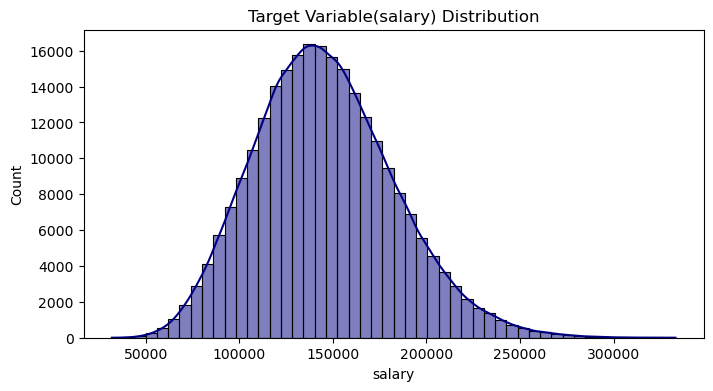

In [10]:
# Target Variable Distribution
fig, ax = plt.subplots(figsize=(8, 4))
sns.histplot(data=df['salary'], bins=50, kde=True, color='navy')
ax.set_title("Target Variable(salary) Distribution")

In [11]:
# Check Correlation
df.corr(numeric_only=True)

,experience_years,skills_count,certifications,salary
experience_years,1.000000,0.000149,-0.000198,0.437627
skills_count,0.000149,1.000000,-0.002230,0.127300
certifications,-0.000198,-0.002230,1.000000,0.073819
salary,0.437627,0.127300,0.073819,1.000000


Text(0.5, 1.0, 'Correlation of all features with salary')

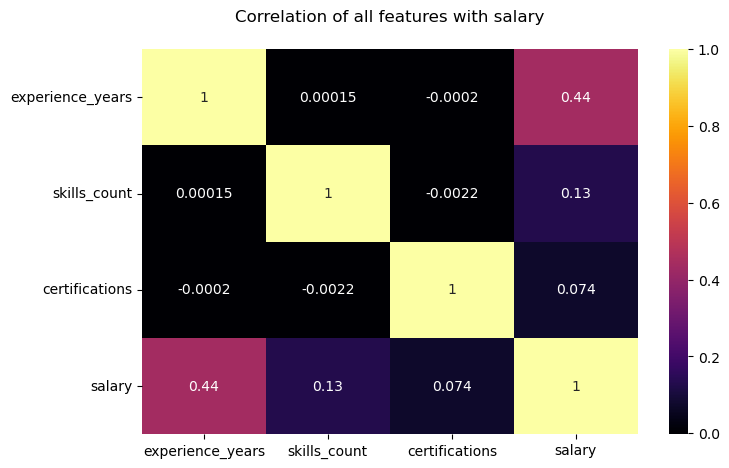

In [12]:
# Correlation Heatmap
fig, ax = plt.subplots(figsize=(8, 5))
sns.heatmap(df.corr(numeric_only=True), cmap='inferno', annot=True)
ax.set_title("Correlation of all features with salary", pad=20)

<Axes: xlabel='salary'>

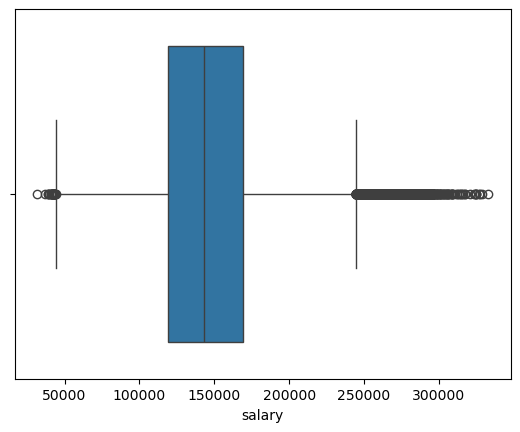

In [13]:
# Boxplot on Target Variable
sns.boxplot(data=df, x='salary')

([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11],
 [Text(0, 0, 'AI Engineer'),
  Text(1, 0, 'Data Analyst'),
  Text(2, 0, 'Frontend Developer'),
  Text(3, 0, 'Business Analyst'),
  Text(4, 0, 'Product Manager'),
  Text(5, 0, 'Backend Developer'),
  Text(6, 0, 'Machine Learning Engineer'),
  Text(7, 0, 'DevOps Engineer'),
  Text(8, 0, 'Software Engineer'),
  Text(9, 0, 'Cybersecurity Analyst'),
  Text(10, 0, 'Data Scientist'),
  Text(11, 0, 'Cloud Engineer')])

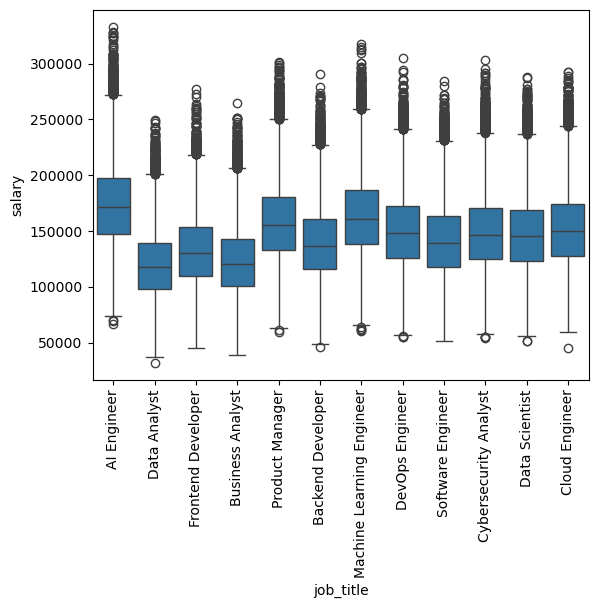

In [14]:
sns.boxplot(data=df, x='job_title', y='salary')
plt.xticks(rotation=90)

<Axes: xlabel='experience_years', ylabel='salary'>

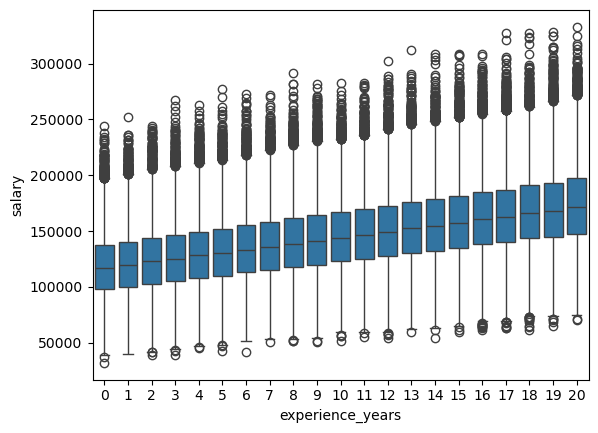

In [15]:
sns.boxplot(data=df, x='experience_years', y='salary')

<Axes: xlabel='skills_count', ylabel='salary'>

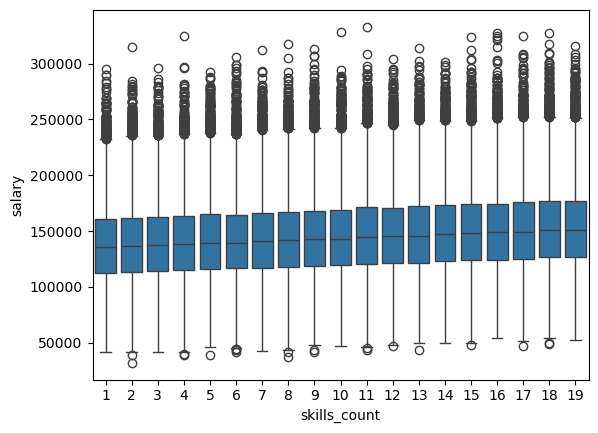

In [16]:
sns.boxplot(data=df, x='skills_count', y='salary')

<Axes: xlabel='education_level', ylabel='salary'>

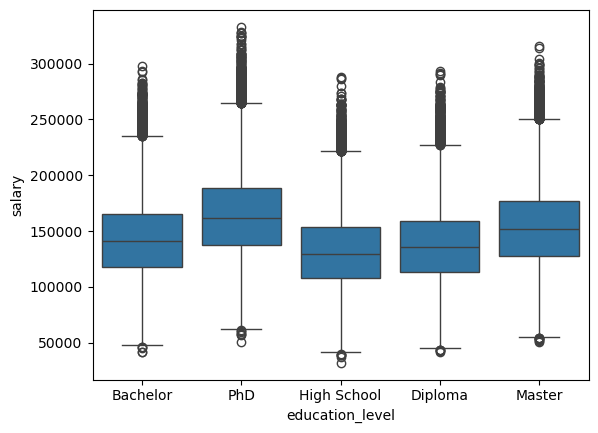

In [17]:
sns.boxplot(data=df, x='education_level', y='salary')

([0, 1, 2, 3, 4, 5, 6, 7, 8, 9],
 [Text(0, 0, 'Healthcare'),
  Text(1, 0, 'Telecom'),
  Text(2, 0, 'Media'),
  Text(3, 0, 'Retail'),
  Text(4, 0, 'Manufacturing'),
  Text(5, 0, 'Education'),
  Text(6, 0, 'Finance'),
  Text(7, 0, 'Technology'),
  Text(8, 0, 'Consulting'),
  Text(9, 0, 'Government')])

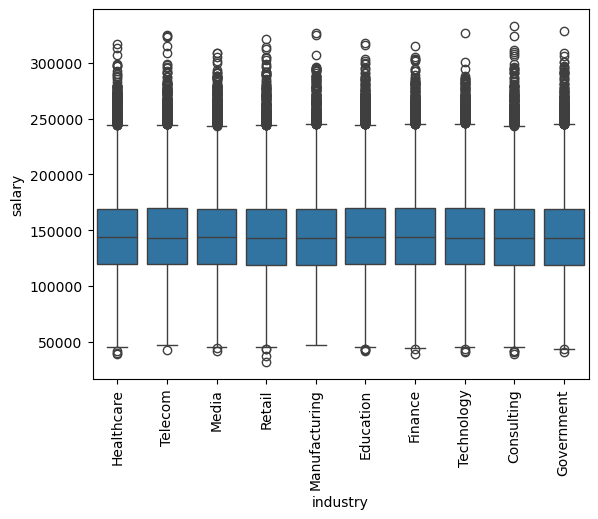

In [18]:
sns.boxplot(data=df, x="industry", y="salary")
plt.xticks(rotation=90)

<Axes: xlabel='remote_work', ylabel='salary'>

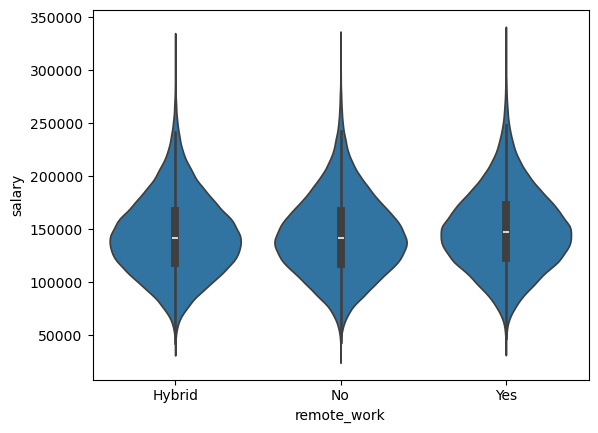

In [19]:
sns.violinplot(data=df, x='remote_work', y='salary')

([0, 1, 2, 3, 4, 5, 6, 7, 8, 9],
 [Text(0, 0, 'India'),
  Text(1, 0, 'Australia'),
  Text(2, 0, 'Singapore'),
  Text(3, 0, 'Canada'),
  Text(4, 0, 'Sweden'),
  Text(5, 0, 'USA'),
  Text(6, 0, 'Netherlands'),
  Text(7, 0, 'Remote'),
  Text(8, 0, 'Germany'),
  Text(9, 0, 'UK')])

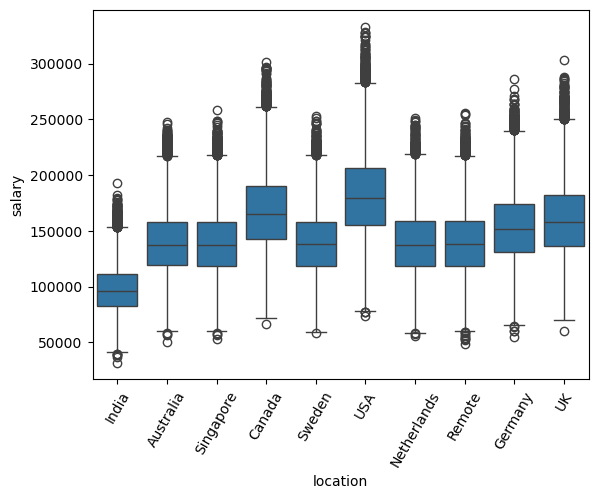

In [20]:
sns.boxplot(data=df, x='location', y='salary')
plt.xticks(rotation=60)

<Axes: xlabel='certifications', ylabel='salary'>

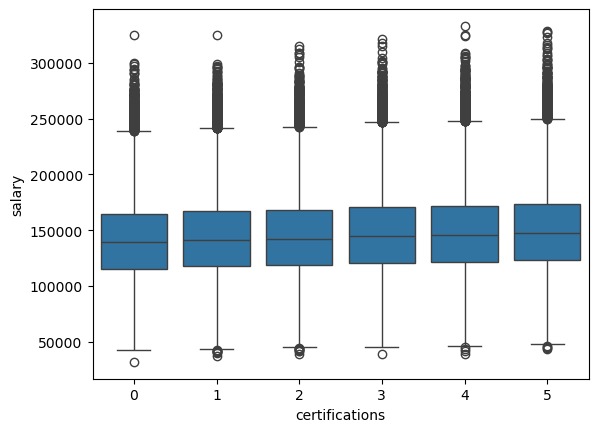

In [21]:
sns.boxplot(data=df, x='certifications', y='salary')

## 2. Feature Engineering

In [22]:
# Separate Independent and Dependent Variable
X = df.drop(columns='salary', axis=1)
y= df['salary']
X.columns

Index(['job_title', 'experience_years', 'education_level', 'skills_count',
       'industry', 'company_size', 'location', 'remote_work',
       'certifications'],
      dtype='object')

In [23]:
# Train Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [24]:
X_train.shape, X_test.shape

((175000, 9), (75000, 9))

In [25]:
df.head()

,job_title,experience_years,education_level,skills_count,industry,company_size,location,remote_work,certifications,salary
0,AI Engineer,10,Bachelor,2,Healthcare,Medium,India,Hybrid,2,109413
1,Data Analyst,5,Bachelor,17,Telecom,Small,Australia,No,0,93764
2,Frontend Developer,18,PhD,4,Media,Medium,Singapore,No,1,148123
3,Business Analyst,19,PhD,13,Retail,Medium,Canada,Yes,0,189123
4,Product Manager,15,Bachelor,7,Manufacturing,Large,Sweden,Yes,0,165069


In [26]:
df['education_level'].value_counts()

education_level
Master         50352
High School    50065
Bachelor       49950
PhD            49857
Diploma        49776
Name: count, dtype: int64

In [27]:
df['company_size'].value_counts()

company_size
Large         50254
Small         50235
Medium        50027
Enterprise    49875
Startup       49609
Name: count, dtype: int64

In [28]:
# Ordinal Encoding
education_level_map = {'High School': 1, 'Diploma': 2, 'Bachelor': 3, 'Master': 4, 'PhD': 5}
company_size_map = {'Startup': 1, 'Small': 2, 'Medium': 3, 'Enterprise': 4, 'Large': 5}

X_train['education_level'] = X_train['education_level'].map(education_level_map)
X_test['education_level'] = X_test['education_level'].map(education_level_map)
X_train['company_size'] = X_train['company_size'].map(company_size_map)
X_test['company_size'] = X_test['company_size'].map(company_size_map)
X_train.head()

,job_title,experience_years,education_level,skills_count,industry,company_size,location,remote_work,certifications
192448,DevOps Engineer,8,5,3,Telecom,1,Singapore,No,2
139604,AI Engineer,11,2,8,Government,2,USA,Yes,5
140914,AI Engineer,20,3,5,Healthcare,1,Remote,No,5
80088,AI Engineer,4,2,4,Manufacturing,1,Canada,No,3
72918,Backend Developer,9,5,15,Government,1,Remote,Hybrid,4


In [29]:
X_train.shape, X_test.shape

((175000, 9), (75000, 9))

In [30]:
df['industry'].value_counts()

industry
Finance          25393
Consulting       25258
Media            25034
Manufacturing    25024
Technology       24903
Government       24901
Healthcare       24898
Education        24889
Telecom          24859
Retail           24841
Name: count, dtype: int64

In [31]:
df['location'].value_counts()

location
Australia      25258
Canada         25165
Sweden         25100
Remote         25065
Singapore      25035
USA            24931
UK             24927
India          24895
Netherlands    24861
Germany        24763
Name: count, dtype: int64

In [32]:
df['remote_work'].value_counts()

remote_work
No        83621
Hybrid    83476
Yes       82903
Name: count, dtype: int64

In [33]:
X_train.shape, X_test.shape

((175000, 9), (75000, 9))

In [34]:
# One Hot Encoding
cat_cols = ['job_title', 'industry', 'location', 'remote_work']

# remainder='passthrough' keeps your numerical features untouched
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore'), cat_cols)
    ],
    remainder='passthrough'
)

X_train_encoded = preprocessor.fit_transform(X_train)
X_test_encoded = preprocessor.transform(X_test)
X_train_encoded

array([[ 0.,  0.,  0., ...,  3.,  1.,  2.],
       [ 0.,  0.,  0., ...,  8.,  2.,  5.],
       [ 0.,  0.,  0., ...,  5.,  1.,  5.],
       ...,
       [ 0.,  0.,  0., ...,  6.,  5.,  0.],
       [ 0.,  0.,  0., ...,  8.,  3.,  2.],
       [ 0.,  1.,  0., ..., 10.,  2.,  2.]])

## 3. Feature Scaling and Train The Model

In [35]:
model_pipeline = Pipeline(steps=[
    ('preprocessing', preprocessor),
    ('scaling', StandardScaler()),
    ('regressor', LinearRegression())
])

model_pipeline.fit(X_train, y_train)

Pipeline(steps=[('preprocessing',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('cat',
                                                  OneHotEncoder(drop='first',
                                                                handle_unknown='ignore',
                                                                sparse_output=False),
                                                  ['job_title', 'industry',
                                                   'location',
                                                   'remote_work'])])),
                ('scaling', StandardScaler()),
                ('regressor', LinearRegression())])

## 4. Prediction of the Test Data

In [36]:
y_pred = model_pipeline.predict(X_test)
y_pred

array([176247.62953675,  91843.33795997,  67101.46083185, ...,
       136075.77251264, 183558.2193001 , 170369.81708974])

In [37]:
y_test

38683     164009
64939      79594
3954       74090
120374    177193
172861    120012
           ...  
246904     94251
213577    144628
175132    129183
75216     195525
145446    157610
Name: salary, Length: 75000, dtype: int64

## Performance Metrics

In [38]:
# Calculate MSE, RMSE, MAE
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred)
print(f"Mean Squared Error: {mse:.4f}")
print(f"Root Mean Squared Error: {rmse:.4f}")
print(f"Mean Absolute Error: {mae:.4f}")

Mean Squared Error: 118155651.2196
Root Mean Squared Error: 10869.9426
Mean Absolute Error: 8439.7389


In [39]:
# Calculate R Square & Adjusted R Square
r2 = r2_score(y_test, y_pred)
print(f"R Square: {r2:.4f}")

adjusted_r2 = 1 - (1-r2)*(len(y_test)-1) / (len(y_test)-X_test.shape[1]-1)
print(f"Adjusted R Square: {adjusted_r2:.4f}")

R Square: 0.9152
Adjusted R Square: 0.9152


In [40]:
# Pickle the Model
with open('models/job_salary_prediction_pipeline.pkl', 'wb') as file:
    pickle.dump(model_pipeline, file)